# Deterministic Pruning Approaches

In [2]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

from stochastic_graph import StochasticGraph
from preprocessing import bfReach, detReach, bfArcFlags, detArcFlags
from SOTA import StandardSOTASolver, SingleIterationSOTASolver
from deterministic_algorithms import Dijkstra

sys.path.append(os.path.abspath("../graph"))

from Grid_network_and_Gamma_distribution import Matrix

import warnings
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")

%matplotlib inline

%load_ext autoreload
%autoreload 2

In [3]:
# loading graph

matrix = Matrix(5, 5, link_var_max=0.5)
adj_matrix, var_matrix = matrix.compute_matrices()

## Step-by-step Arc-flags explanation

### 1. Dividing graph into partitions

We divide the graph into partition using K-means algorithm.

In [12]:
adj_matrix, var_matrix = matrix.get_matrices()
g = StochasticGraph(adj_matrix, var_matrix)
d = Dijkstra(adj_matrix)

f = detArcFlags(g, 4, d, 20)

c:\ProgramData\miniconda3\envs\myenv\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


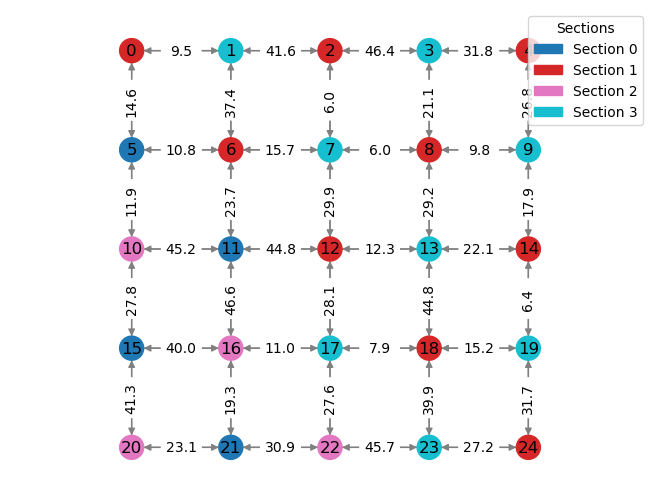

In [6]:
f.partition_graph()
f.print_graph_sections()

### 2. Computing Arcflags

#### 2.1 Computing the optimal path from $start \in V$ to all nodes

`compute_path(start_node)` function computes the optimal path from source node to all nodes and returns a list of predecessors; for each node I'll have the optimal predecessor.

In [14]:
start = 0

pred_s = d.compute_path(start)
pred_s

{0: [],
 1: [0],
 5: [0],
 6: [5],
 10: [5],
 2: [1],
 7: [6],
 11: [10],
 15: [10],
 12: [11],
 16: [11],
 3: [2],
 17: [16],
 21: [16],
 13: [12],
 20: [15],
 18: [17],
 22: [17],
 8: [7],
 14: [13],
 23: [22],
 9: [14],
 19: [14],
 24: [23],
 4: [3]}

Note: if we have multiple predecessors for one or more nodes, I'll get multiple optimal paths.

#### 2.2 For each destination $dest\in V$, I'll get the optimal path and optimal edges set

In [13]:
dest = 18

opt_paths = d.get_all_optimal_paths(pred_s, dest)
print(opt_paths)
visited_edges = d.get_edges_from_optimal_paths(opt_paths)
print(visited_edges)

[[0, 5, 10, 11, 16, 17, 18]]
{(10, 11), (11, 16), (5, 10), (0, 5), (17, 18), (16, 17)}


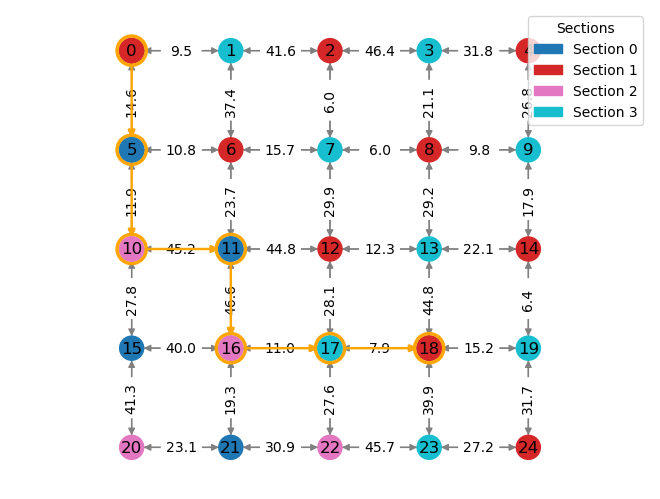

In [38]:
f.print_graph_sections(path=opt_paths[0])

#### 2.3 Updating $AF$ structure

I'll set the corresponding $dest$ region to $\text{TRUE}$ for all the `visited_edges`

### 3. Pruning

In [40]:
f.arcflags_computation()
f.print_arcflags()

Executing partition...
Partitioning of the graph in 4 regions executed in 0.0198 seconds!
Computing arcflags...
Arcflags computed!
Arc-Flags for each edge:
Edge (np.int64(0), np.int64(1)): {0: False, 1: True, 2: False, 3: True}
Edge (np.int64(0), np.int64(5)): {0: True, 1: True, 2: True, 3: True}
Edge (np.int64(1), np.int64(0)): {0: False, 1: True, 2: False, 3: False}
Edge (np.int64(1), np.int64(2)): {0: False, 1: True, 2: False, 3: True}
Edge (np.int64(1), np.int64(6)): {0: True, 1: True, 2: True, 3: True}
Edge (np.int64(2), np.int64(1)): {0: False, 1: True, 2: False, 3: True}
Edge (np.int64(2), np.int64(3)): {0: False, 1: True, 2: False, 3: True}
Edge (np.int64(2), np.int64(7)): {0: True, 1: True, 2: True, 3: True}
Edge (np.int64(3), np.int64(2)): {0: False, 1: False, 2: False, 3: False}
Edge (np.int64(3), np.int64(4)): {0: False, 1: True, 2: False, 3: False}
Edge (np.int64(3), np.int64(8)): {0: True, 1: True, 2: True, 3: True}
Edge (np.int64(4), np.int64(3)): {0: True, 1: True, 2: T

I'll retrieve destination region and prune the edge if the arcflag is $=\text{FALSE}$.